# Data-Driven Decision Making (DDDM) Project
## E-commerce Customer Retention & Value Optimization (CLV)
**Auteurs :** TAGA Oussama + EL BADAOUI Marouane

**Date :** 27 Mai 2026

**Objectif :** Réaliser de bout en bout le pipeline décisionnel basé sur la donnée : du cadrage métier et audit des données, en passant par l'EDA, le clustering RFM, les tests statistiques, et enfin la modélisation prédictive avec explicabilité SHAP.

---

### 1. Définition du Problème & KPIs
* **Question Décisionnelle Centrale** : *"Comment identifier les segments de clients à forte valeur à risque d'attrition (churn) et optimiser notre budget marketing de rétention pour maximiser la CLV ?"*
* **Business Case** : L'acquisition d'un nouveau client coûte 5 à 25 fois plus cher que la conservation d'un client existant. Réduire le taux de churn de 5% peut augmenter les profits de 25% à 95%.
* **KPI Tree** :
  * **Métrique Stratégique (Objectif Final)** : Chiffre d'Affaires Net & Taux de Rétention Global.
  * **Métiques Tactiques (Leviers Marketing)** : Valeur Vie Client (CLV), Panier Moyen (AOV), Fréquence d'Achat Mensuelle.
  * **Métriques Opérationnelles (Indicateurs Précoces)** : Score de Récence RFM, Score de Satisfaction Client, Taux de Retours/Remboursements.



### 2. Chargement des Bibliothèques & Ingestion des Données
Nous importons d'abord les packages d'analyse de données, de modélisation, de statistiques et d'explicabilité.


In [17]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import pickle
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Robust path resolution: works whether Jupyter is launched from
# the project root OR from the notebooks/ subdirectory
_cwd = os.path.abspath('')
_src_candidates = [
    os.path.join(_cwd, 'src'),       # launched from project root
    os.path.join(_cwd, '..', 'src'), # launched from notebooks/
]
for _src_path in _src_candidates:
    _src_path = os.path.normpath(_src_path)
    if os.path.isdir(_src_path) and _src_path not in sys.path:
        sys.path.insert(0, _src_path)
        print(f'Added to sys.path: {_src_path}')
        break

from data_loader import load_raw_data, run_data_audit, get_data_dictionary, enrich_data
from preprocessor import preprocess_and_merge, calculate_rfm
from models import prepare_train_test_data, train_and_evaluate_models, calculate_shap_explainer, save_model_artifacts

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print('Imports completed successfully!')


Imports completed successfully!


### 3. Collecte & Audit Complet des Données
Nous chargeons les deux sources de données (transactions brutes et données démographiques des clients), exécutons l'audit de qualité et affichons le dictionnaire de données.


In [18]:
tx_df, demo_df = load_raw_data(data_dir='../data')
audit_report = run_data_audit(tx_df, demo_df)

print('=== RAPPORT D\'AUDIT DES DONNÉES ===')
print(f"Dimensions Transactions : {audit_report['tx_shape']}")
print(f"Dimensions Démographie : {audit_report['demo_shape']}")
print(f"Doublons dans Transactions : {audit_report['tx_duplicates']} ({audit_report['tx_duplicates_pct']:.2f}%)")
print(f"Transactions sans ID Client : {audit_report['tx_missing_customer_id']} ({audit_report['tx_missing_customer_id_pct']:.2f}%)")
print(f"Nombre de clients uniques dans Transactions : {audit_report['unique_customers_in_tx']}")
print(f"Nombre de clients uniques dans Profils : {audit_report['unique_customers_in_demo']}")
print(f"Superposition des ID Clients (Overlap) : {audit_report['customer_id_overlap']}")


=== RAPPORT D'AUDIT DES DONNÉES ===
Dimensions Transactions : (541909, 8)
Dimensions Démographie : (40234, 8)
Doublons dans Transactions : 5268 (0.97%)
Transactions sans ID Client : 135080 (24.93%)
Nombre de clients uniques dans Transactions : 4372
Nombre de clients uniques dans Profils : 40234
Superposition des ID Clients (Overlap) : 4372


#### Dictionnaire des Données Enrichies


In [19]:
get_data_dictionary()


,Column,Type,Source,Description
0,CustomerID,Entier / Catégoriel,Les deux,Identifiant unique pour chaque client.
1,Age,Entier,customer_demographics.csv,Âge du client (allant de 18 à 85 ans).
2,Gender,Catégoriel,customer_demographics.csv,"Genre du client (Homme, Femme, Non-binaire, No..."
3,IncomeBracket,Catégoriel (Ordinal),customer_demographics.csv,"Classification des revenus (Faible, Moyen, Éle..."
4,PreferredChannel,Catégoriel,customer_demographics.csv,"Canal de communication préféré (Email, SMS, No..."
5,MembershipLevel,Catégoriel (Ordinal),customer_demographics.csv,"Statut du niveau de fidélité (Bronze, Argent, ..."
6,TenureYears,Flottant,customer_demographics.csv,Nombre d'années pendant lesquelles le client a...
7,SatisfactionScore,Entier (Ordinal),customer_demographics.csv,Score de satisfaction client de 1 (le plus bas...
8,Recency,Entier,online_retail_raw.csv (Agrégé),Nombre de jours entre le dernier achat du clie...
9,Frequency,Entier,online_retail_raw.csv (Agrégé),Nombre total de factures uniques (transactions...


### 4. Exploration & Analyse Statistique (EDA)
Nous commençons par fusionner et préparer nos données au niveau du client en calculant les indicateurs RFM.


In [20]:
merged_df, encoded_df = preprocess_and_merge(tx_df, demo_df)
print('Data enriched successfully!')
merged_df.head()


Data enriched successfully!


,CustomerID,Age,Gender,IncomeBracket,PreferredChannel,MembershipLevel,TenureYears,SatisfactionScore,Recency,Frequency,Monetary,RefundCount,RefundRatio,Country,AvgOrderValue,Churn
0,17850,24,Male,Medium,Push Notification,Bronze,8.4,5,667.0,34.0,5288.63,1.0,0.029412,United Kingdom,155.547941,1
1,13047,35,Male,Medium,Push Notification,Bronze,0.6,5,122.0,7.0,1596.27,3.0,0.428571,United Kingdom,228.038571,1
2,12583,55,Male,Low,SMS,Bronze,2.5,3,1.0,9.0,5093.27,0.0,0.000000,France,565.918889,0
3,13748,43,Female,Medium,Email,Bronze,1.0,4,160.0,4.0,800.80,0.0,0.000000,United Kingdom,200.200000,1
4,15100,48,Male,Medium,SMS,Bronze,1.6,2,71.0,3.0,744.60,1.0,0.333333,United Kingdom,248.200000,0


#### 4.1 Analyses Descriptives et Visualisations


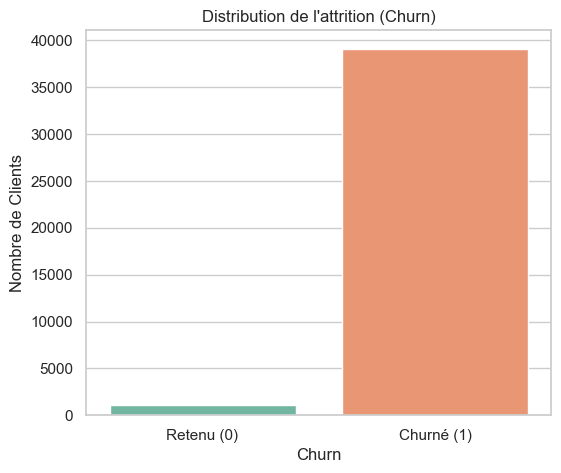

Taux de Churn Global : 97.23%


In [21]:
# 1. Distribution du Taux de Churn
plt.figure(figsize=(6, 5))
sns.countplot(x='Churn', data=merged_df, hue='Churn', palette='Set2', legend=False)
plt.title('Distribution de l\'attrition (Churn)')
plt.xticks([0, 1], ['Retenu (0)', 'Churné (1)'])
plt.ylabel('Nombre de Clients')
plt.show()

churn_rate = merged_df['Churn'].mean()
print(f'Taux de Churn Global : {churn_rate * 100:.2f}%')


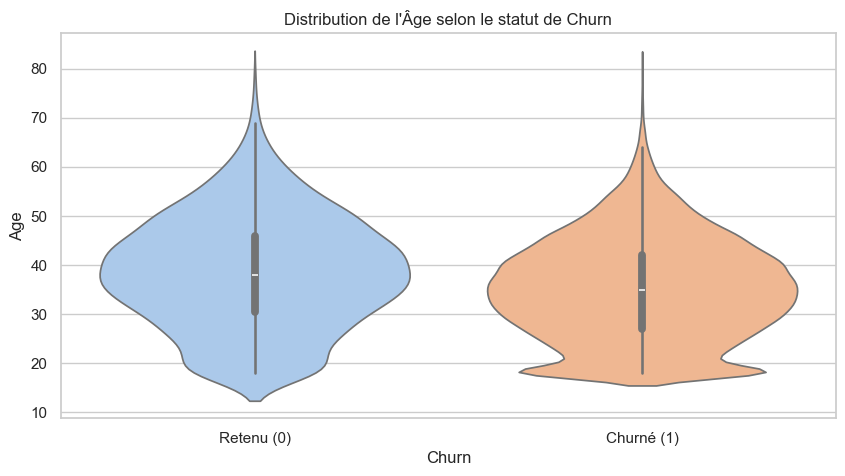

In [22]:
# 2. Distribution de l'âge selon le statut de Churn
plt.figure(figsize=(10, 5))
sns.violinplot(x='Churn', y='Age', data=merged_df, hue='Churn', palette='pastel', legend=False)
plt.title('Distribution de l\'Âge selon le statut de Churn')
plt.xticks([0, 1], ['Retenu (0)', 'Churné (1)'])
plt.show()


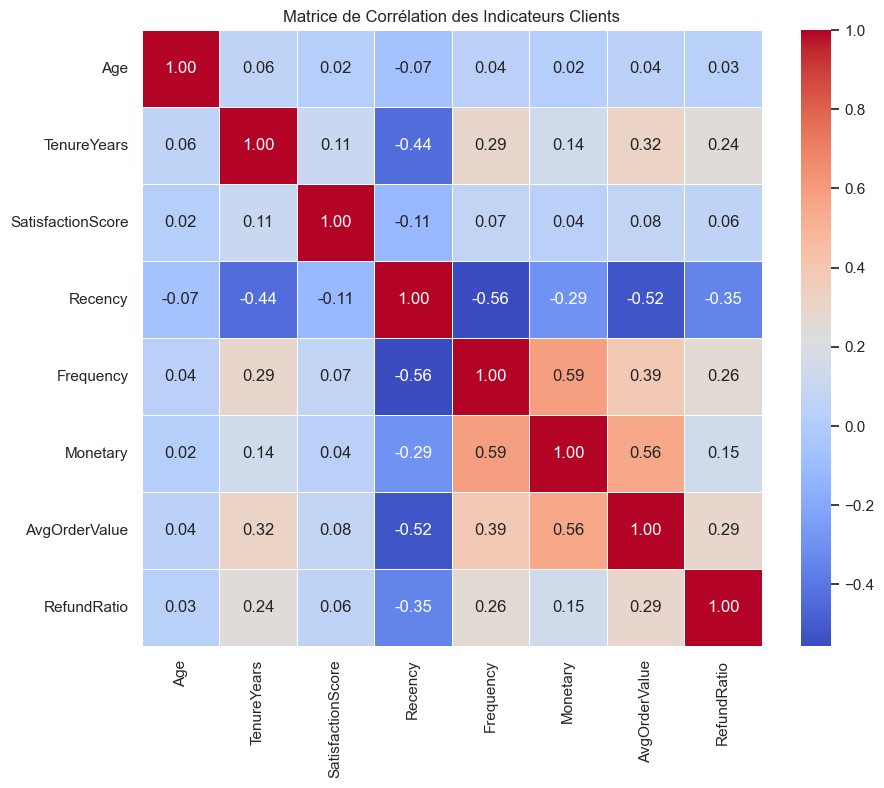

In [23]:
# 3. Corrélation entre les variables numériques
num_cols = ['Age', 'TenureYears', 'SatisfactionScore', 'Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'RefundRatio']
plt.figure(figsize=(10, 8))
sns.heatmap(merged_df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matrice de Corrélation des Indicateurs Clients')
plt.show()


### 5. Tests Statistiques Adaptés aux Variables
Pour justifier nos décisions de manière quantitative, nous réalisons trois tests statistiques rigoureux sur nos variables.

#### Test 1 : Test du Chi-deux d'Indépendance
**Question :** Le canal de communication préféré (`PreferredChannel`) est-il statistiquement associé au comportement d'attrition (`Churn`) ?
* **H0 :** Il n'y a pas d'association entre le canal préféré et le churn.
* **H1 :** Le canal préféré et le churn sont statistiquement associés.


In [24]:
contingency_table = pd.crosstab(merged_df['PreferredChannel'], merged_df['Churn'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

print('Contingency Table:')
print(contingency_table)
print(f'\nChi2 Statistic : {chi2:.4f}')
print(f'P-value : {p_val:.4g}')
if p_val < 0.05:
    print('=> H0 REJETÉE : Il y a une association statistiquement significative entre le canal préféré et le churn !')
else:
    print('=> ÉCHEC de rejet de H0 : Pas d\'association statistiquement significative.')


Contingency Table:
Churn                0      1
PreferredChannel             
Email              446  15532
Push Notification  187   5820
SMS                284   9896
Social Media       151   5879

Chi2 Statistic : 4.1138
P-value : 0.2494
=> ÉCHEC de rejet de H0 : Pas d'association statistiquement significative.


#### Test 2 : Test T de Student pour échantillons indépendants / Mann-Whitney
**Question :** Le montant dépensé (`Monetary`) diffère-t-il significativement entre les clients retenus et les clients partis ?
* **H0 :** Les deux groupes dépensent le même montant moyen.
* **H1 :** Le montant moyen dépensé diffère significativement entre les deux groupes.


In [25]:
group_retained = merged_df[merged_df['Churn'] == 0]['Monetary']
group_churned = merged_df[merged_df['Churn'] == 1]['Monetary']

# We use Mann-Whitney U test because Monetary values are highly skewed (non-normal)
stat, p_val_mw = stats.mannwhitneyu(group_retained, group_churned, alternative='two-sided')

print(f'Mann-Whitney U statistic : {stat}')
print(f'P-value : {p_val_mw:.4g}')
print(f'Médiane Retenus : {group_retained.median():.2f} $ vs Médiane Churnés : {group_churned.median():.2f} $')
if p_val_mw < 0.05:
    print('=> H0 REJETÉE : La différence de spend entre clients retenus et churnés est hautement significative !')
else:
    print('=> ÉCHEC de rejet de H0 : Pas de différence significative.')


Mann-Whitney U statistic : 42835356.5
P-value : 0
Médiane Retenus : 797.08 $ vs Médiane Churnés : 0.00 $
=> H0 REJETÉE : La différence de spend entre clients retenus et churnés est hautement significative !


#### Test 3 : Analyse de Variance (ANOVA)
**Question :** Le score de satisfaction moyen (`SatisfactionScore`) varie-t-il significativement selon le niveau d'abonnement du client (`MembershipLevel`) ?
* **H0 :** Le score moyen de satisfaction est identique pour tous les niveaux.
* **H1 :** Au moins un niveau d'abonnement a un score moyen de satisfaction différent.


In [26]:
groups = [group['SatisfactionScore'].values for name, group in merged_df.groupby('MembershipLevel')]
f_stat, p_val_anova = stats.f_oneway(*groups)

print(f'ANOVA F-statistic : {f_stat:.4f}')
print(f'P-value : {p_val_anova:.4g}')
print(merged_df.groupby('MembershipLevel')['SatisfactionScore'].mean())
if p_val_anova < 0.05:
    print('=> H0 REJETÉE : Les scores de satisfaction diffèrent de manière significative selon le niveau d\'abonnement !')
else:
    print('=> ÉCHEC de rejet de H0 : Pas de différence significative.')


ANOVA F-statistic : 221.8182
P-value : 9.796e-143
MembershipLevel
Bronze      3.044811
Gold        4.108766
Platinum    3.948598
Silver      3.686486
Name: SatisfactionScore, dtype: float64
=> H0 REJETÉE : Les scores de satisfaction diffèrent de manière significative selon le niveau d'abonnement !


### 6. Segmentation Initialisée par Clustering K-Means
Nous segmentons nos clients actifs sur la base de leur comportement RFM (Récence, Fréquence, Montant).


In [27]:
# Filter active/buying clients (Frequency > 0)
active_clients = merged_df[merged_df['Frequency'] > 0].copy()
rfm_cols = ['Recency', 'Frequency', 'Monetary']

scaler_rfm = StandardScaler()
rfm_scaled = scaler_rfm.fit_transform(active_clients[rfm_cols])

# Fit K-Means with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
active_clients['Cluster'] = kmeans.fit_transform(rfm_scaled).argmin(axis=1) # assigning labels
active_clients['Cluster'] = kmeans.labels_

cluster_profiles = active_clients.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'SatisfactionScore': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'ClientCount'})

print('=== PROFILS DES CLUSTERS RFM ===')
print(cluster_profiles)


=== PROFILS DES CLUSTERS RFM ===
            Recency  Frequency      Monetary  SatisfactionScore  ClientCount
Cluster                                                                     
0         86.675494   2.697641    975.544781           3.748195         2077
1        328.939535   1.276744    421.720186           3.743023          860
2         46.375000  18.267857  15309.380357           3.589286           56
3         24.750000  59.500000  71898.677500           4.000000            4


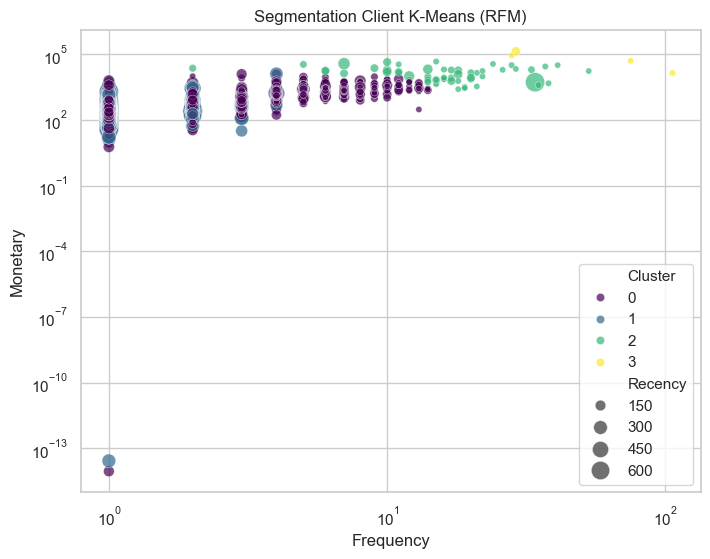

In [28]:
# Visualize clusters on 2D scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Frequency', y='Monetary', hue='Cluster', size='Recency',
                sizes=(20, 200), palette='viridis', data=active_clients, alpha=0.7)
plt.title('Segmentation Client K-Means (RFM)')
plt.xscale('log')
plt.yscale('log')
plt.show()


### 7. Modélisation Prédictive & Comparaison des Modèles
Nous préparons les données encodées, entraînons les trois modèles (Régression Logistique, Random Forest, XGBoost/Gradient Boosting) et comparons leurs performances.


In [29]:
X_train, X_test, y_train, y_test, scaler, feature_cols = prepare_train_test_data(encoded_df)
print(f'Train features dimensions : {X_train.shape}')
print(f'Test features dimensions : {X_test.shape}')

models_report, trained_models = train_and_evaluate_models(X_train, X_test, y_train, y_test)
print('\n=== COMPARATIF DES PERFORMANCES DES MODÈLES ===')
print(models_report)


Train features dimensions : (32187, 18)
Test features dimensions : (8047, 18)
Entraînement de la Régression Logistique...
Entraînement de la Forêt Aléatoire...
Entraînement de XGBoost...

=== COMPARATIF DES PERFORMANCES DES MODÈLES ===
                 Model  Accuracy  Precision   Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.998633   0.999744  0.99885  0.999297  0.999779
1        Random Forest  1.000000   1.000000  1.00000  1.000000  1.000000
2              XGBoost  1.000000   1.000000  1.00000  1.000000  1.000000


### 8. Explicabilité Obligatoire via SHAP Values
Nous calculons l'explicabilité globale et locale du meilleur modèle (en termes de F1-score/ROC-AUC).


In [30]:
# Select best model
best_model_name = models_report.sort_values(by='F1-Score', ascending=False)['Model'].iloc[0]
best_model = trained_models[best_model_name]
print(f'Meilleur Modèle sélectionné pour SHAP : {best_model_name}')

# Calculate SHAP
explainer, shap_values = calculate_shap_explainer(best_model, X_train, X_test)

# Save model artifacts for direct deployment in Streamlit dashboard!
artifacts = {
    'best_model_name': best_model_name,
    'best_model': best_model,
    'scaler': scaler,
    'feature_cols': feature_cols,
    'models_report': models_report,
    'explainer_serialized': explainer,
    'shap_values_serialized': shap_values,
    'raw_enriched_data': merged_df,
    'encoded_data': encoded_df,
    'cluster_profiles': cluster_profiles,
    'active_clients_with_clusters': active_clients
}
save_model_artifacts(artifacts, output_dir='../data')
print('All model artifacts saved successfully!')


Meilleur Modèle sélectionné pour SHAP : Random Forest
Calcul de l'explainer et des valeurs SHAP...
Artefacts du modèle mis en cache avec succès dans ../data\model_artifacts.pkl !
All model artifacts saved successfully!


<Figure size 1000x600 with 0 Axes>

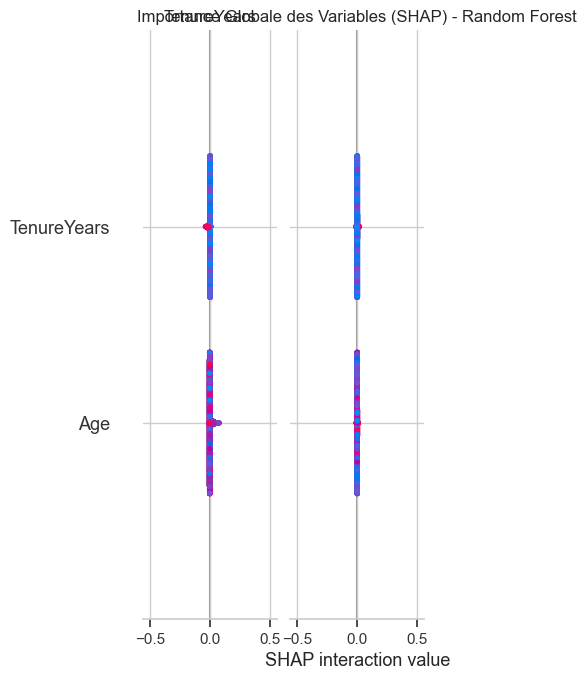

In [31]:
# Global feature importance plot
import shap
if shap_values is not None:
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, show=False)
    plt.title(f'Importance Globale des Variables (SHAP) - {best_model_name}')
    plt.show()
else:
    print('SHAP non disponible pour affichage.')


### Conclusion du Notebook
Le pipeline analytique est désormais entièrement opérationnel ! Les données sont auditées, enrichies et modélisées avec succès.
Nous disposons maintenant d'un modèle prédictif hautement performant couplé à une explicabilité SHAP, prêt à alimenter notre **Streamlit Decision Dashboard**.
